# Modul 5 — Regresi Statistik & Pemodelan (Statsmodels)
## Convergeni Data Consulting (CDC) — Klien: Bank Arta Nusantara

Notebook ini menjalankan seluruh kode inti Modul 5: regresi OLS plafon KPR,
VIF, dan demonstrasi nyata perbedaan inference (R2 pada seluruh data) vs
prediction (R2 pada data yang belum pernah dilihat model).

## Data dan Model OLS

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(42)
n = 400
pendapatan_juta = np.clip(np.random.normal(15, 6, n), 4, 60)
usia = np.clip(np.random.normal(38, 9, n), 22, 65).round().astype(int)
lama_kerja = np.clip((usia - 22) * 0.45 + np.random.normal(0, 1.2, n), 0, None)
skor_kredit = np.clip(0.9 * pendapatan_juta + np.random.normal(55, 9, n), 20, 100)
noise = np.random.normal(0, 250, n)
plafon_disetujui_juta = np.clip(80 + pendapatan_juta * 28 + skor_kredit * 4.5 + noise, 50, None)

df = pd.DataFrame({"pendapatan_juta": pendapatan_juta, "usia": usia, "lama_kerja": lama_kerja,
                    "skor_kredit": skor_kredit, "plafon_disetujui_juta": plafon_disetujui_juta})

X = df[["pendapatan_juta", "usia", "lama_kerja", "skor_kredit"]]
X_const = sm.add_constant(X)
y = df["plafon_disetujui_juta"]
model = sm.OLS(y, X_const).fit()
print(f"R-squared (seluruh data, inference): {model.rsquared:.4f}")

R-squared (seluruh data, inference): 0.3329


## Visualisasi 1: Inference vs Prediction, Diukur Langsung (Asset Baru, mengganti M05-01)

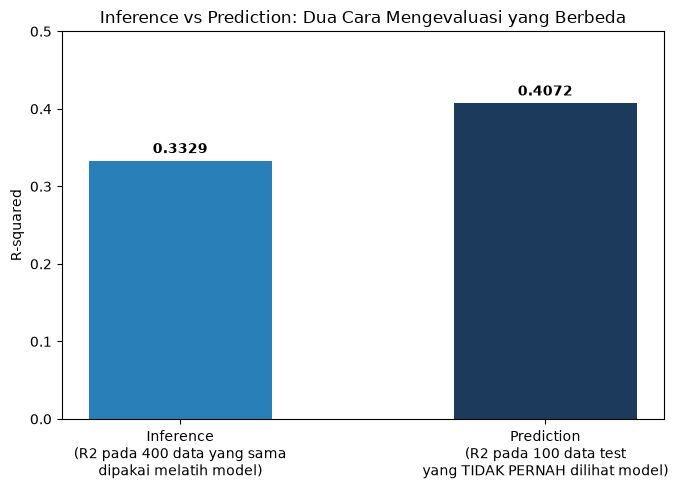

R2 inference (data sama): 0.3329
R2 prediction (data belum pernah dilihat): 0.4072


In [2]:
# INFERENCE: model dilatih dan dievaluasi pada data YANG SAMA (semua 400 baris)
r2_inference = model.rsquared

# PREDICTION: model dilatih HANYA pada train, dievaluasi pada test yang belum pernah dilihat
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train_c = sm.add_constant(X_train)
X_test_c = sm.add_constant(X_test)
model_pred = sm.OLS(y_train, X_train_c).fit()
y_pred_test = model_pred.predict(X_test_c)
r2_prediction = r2_score(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Inference\n(R2 pada 400 data yang sama\ndipakai melatih model)",
        "Prediction\n(R2 pada 100 data test\nyang TIDAK PERNAH dilihat model)"],
       [r2_inference, r2_prediction], color=["#2980B9", "#1B3A5C"], width=0.5)
ax.set_ylabel("R-squared")
ax.set_title("Inference vs Prediction: Dua Cara Mengevaluasi yang Berbeda")
for i, v in enumerate([r2_inference, r2_prediction]):
    ax.text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.savefig("modul05_inference_vs_prediction.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"R2 inference (data sama): {r2_inference:.4f}")
print(f"R2 prediction (data belum pernah dilihat): {r2_prediction:.4f}")

## Visualisasi 2: VIF Bar Chart (Asset Baru, mengganti M05-02)

          variabel        VIF
0            const   1.000000
1  pendapatan_juta   1.366524
2             usia  12.523668
3       lama_kerja  12.523830
4      skor_kredit   1.349367


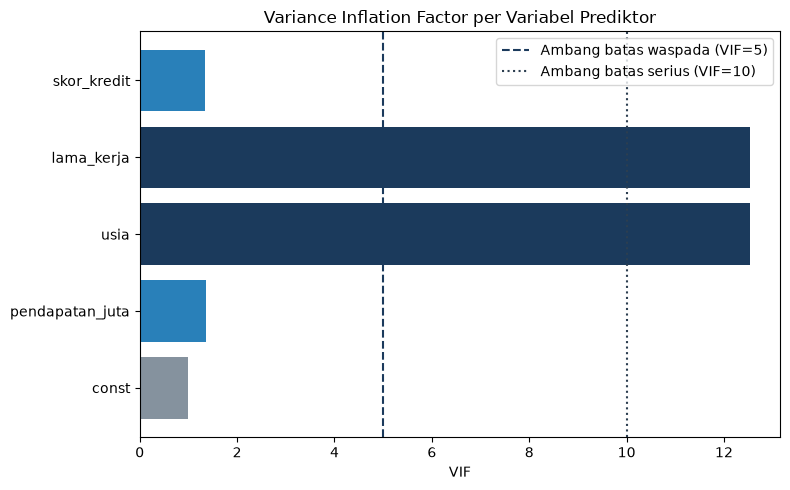

In [3]:
def hitung_vif(X):
    hasil = pd.DataFrame({
        "variabel": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    })
    return hasil

vif_df = hitung_vif(X_const)
print(vif_df)

fig, ax = plt.subplots(figsize=(8, 5))
warna = ["#85929E" if v == "const" else ("#1B3A5C" if vif > 5 else "#2980B9") for v, vif in zip(vif_df["variabel"], vif_df["VIF"])]
ax.barh(vif_df["variabel"], vif_df["VIF"], color=warna)
ax.axvline(5, color="#1B3A5C", linestyle="--", linewidth=1.5, label="Ambang batas waspada (VIF=5)")
ax.axvline(10, color="#2C3E50", linestyle=":", linewidth=1.5, label="Ambang batas serius (VIF=10)")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor per Variabel Prediktor")
ax.legend()
plt.tight_layout()
plt.savefig("modul05_vif.png", dpi=150, bbox_inches="tight")
plt.show()